# Pareto Local Search (PLS) — Two-Player Top Trumps

Dieses Notebook verfeinert die beste bisher gefundene Pareto-Front (aus NSGA-II mit optimierten Hyperparametern)
mittels **Pareto Local Search (PLS)**.

**Idee:** PLS ist ein lokaler Suchalgorithmus für Multi-Objective-Probleme. Er startet mit einem bestehenden
Archiv nicht-dominierter Lösungen und versucht, dieses durch systematische Nachbarschaftssuche zu verbessern.

**Vorgehen (Paquete, Chiarandini & Stützle, 2004):**
1. Lade die gespeicherte Pareto-Front als initiales Archiv
2. Markiere alle Lösungen als "unexplored"
3. Für jede unexplored Lösung: Erzeuge Nachbarn, evaluiere sie, aktualisiere das Archiv
4. Wiederhole bis keine Verbesserung mehr oder Budget erschöpft

**Herausforderung:** Das Problem ist stochastisch (Monte-Carlo Simulation). Daher:
- Paired Evaluation mit Common Random Numbers (CRN) für fairen Vergleich
- Re-Evaluation bestehender Lösungen mit denselben Seeds
- Multi-Scale Nachbarschaft (kleine + große Schritte)

**Setup:**
- K=22, L=4, Two-Player (p4 vs p0)
- Initiale Front: 99 Lösungen aus NSGA-II (HV ≈ 4.2816)

In [15]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time
import json
import sys
from pathlib import Path
from pymoo.indicators.hv import HV

sys.path.insert(0, str(Path('..').resolve()))
from simulation import TopTrumpsSimulation, evaluate_deck_detailed

plt.style.use('seaborn-v0_8-whitegrid')

RESULTS_DIR = Path('../results')
PLOTS_DIR = Path('../plots/pls')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Konfiguration

### Anpassungen gegenüber V1 (die nichts fand):

| Parameter | V1 (alt) | V2 (neu) | Begründung |
|---|---|---|---|
| R | 2500 | 5000 | Weniger Rauschen → bessere Dominanz-Erkennung |
| SIGMA | 0.5 | Multi-Scale: [0.3, 1.0, 2.5] | Kleine UND große Schritte |
| FRAC_PERTURB | 0.15 (13 Vars) | Multi-Scale: [0.1, 0.3, 0.6] | Von feinem Tuning bis Restrukturierung |
| Dominanz-Check | Einfach | Paired mit CRN | Eliminiert Rauschen im Vergleich |
| N_NEIGHBORS | 10 | 15 | Mehr Exploration pro Lösung |
| MAX_ITERATIONS | 5 | 10 | Mehr Durchläufe erlaubt |

In [16]:
K = 22
L = 4
N_VAR = K * L  # 88 Entscheidungsvariablen
XL, XU = 1.0, 10.0

R_PLS = 5000             # Simulationen pro Evaluation (erhöht für weniger Rauschen)
N_NEIGHBORS = 15         # Nachbarn pro Lösung pro Iteration
MAX_ITERATIONS = 10      # Maximale PLS-Iterationen
SEED = 42

NEIGHBOR_PROFILES = [
    {'sigma': 0.3, 'frac': 0.10, 'weight': 3, 'label': 'fein'},
    {'sigma': 1.0, 'frac': 0.30, 'weight': 5, 'label': 'mittel'},
    {'sigma': 2.5, 'frac': 0.60, 'weight': 5, 'label': 'grob'},
    {'sigma': 0.5, 'frac': 1.00, 'weight': 2, 'label': 'global-fein'},
]

REF_POINT = np.array([0.0, 0.0])

total_weight = sum(p['weight'] for p in NEIGHBOR_PROFILES)

print(f"Setup: K={K}, L={L}, n_var={N_VAR}")
print(f"\nPLS Parameter:")
print(f"  R (Simulationen): {R_PLS}")
print(f"  Nachbarn pro Lösung: {N_NEIGHBORS}")
print(f"  Max Iterationen: {MAX_ITERATIONS}")
print(f"\nNachbarschafts-Profile:")
for p in NEIGHBOR_PROFILES:
    n = int(round(N_NEIGHBORS * p['weight'] / total_weight))
    print(f"  {p['label']:>12}: σ={p['sigma']}, frac={p['frac']} "
          f"({int(p['frac']*N_VAR)} vars), ~{n} Nachbarn")

Setup: K=22, L=4, n_var=88

PLS Parameter:
  R (Simulationen): 5000
  Nachbarn pro Lösung: 15
  Max Iterationen: 10

Nachbarschafts-Profile:
          fein: σ=0.3, frac=0.1 (8 vars), ~3 Nachbarn
        mittel: σ=1.0, frac=0.3 (26 vars), ~5 Nachbarn
          grob: σ=2.5, frac=0.6 (52 vars), ~5 Nachbarn
   global-fein: σ=0.5, frac=1.0 (88 vars), ~2 Nachbarn


## 2. Initiale Pareto-Front laden

In [17]:
initial_X = np.load(RESULTS_DIR / 'final_pareto_front_X.npy')
initial_F = np.load(RESULTS_DIR / 'final_pareto_front_F.npy')

initial_hv = HV(ref_point=REF_POINT)(initial_F)

print(f"Initiale Pareto-Front geladen:")
print(f"  Lösungen: {len(initial_F)}")
print(f"  Hypervolume (gespeichert, R=2500): {initial_hv:.4f}")
print(f"  Fairness (Win Rate): [{-initial_F[:,0].max():.4f}, {-initial_F[:,0].min():.4f}]")
print(f"  Excitement (Trick Changes): [{-initial_F[:,1].max():.4f}, {-initial_F[:,1].min():.4f}]")

Initiale Pareto-Front geladen:
  Lösungen: 99
  Hypervolume (gespeichert, R=2500): 4.2816
  Fairness (Win Rate): [0.6404, 0.9240]
  Excitement (Trick Changes): [2.4024, 4.8976]


## 3. Re-Evaluation der initialen Front mit R=5000

Die gespeicherten F-Werte wurden mit R=2500 berechnet. Für einen fairen Vergleich
re-evaluieren wir alles mit dem gleichen R.

In [18]:
sim = TopTrumpsSimulation(num_cards=K, num_categories=L)

print(f"Re-Evaluation der initialen Front mit R={R_PLS}...")
start_reeval = time.time()

reeval_F = []
for i, x in enumerate(initial_X):
    stats = evaluate_deck_detailed(sim, x, R_PLS)
    reeval_F.append([-stats['win_rate'], -stats['trick_changes']])
    if (i + 1) % 25 == 0 or i == 0:
        elapsed = time.time() - start_reeval
        eta = elapsed / (i+1) * (len(initial_X) - i - 1)
        print(f"  [{i+1:3d}/{len(initial_X)}] {elapsed:.0f}s elapsed, ~{eta:.0f}s ETA")

reeval_F = np.array(reeval_F)
reeval_hv = HV(ref_point=REF_POINT)(reeval_F)

print(f"\nRe-Evaluation in {time.time()-start_reeval:.0f}s")
print(f"  HV (alt, R=2500): {initial_hv:.4f}")
print(f"  HV (neu, R={R_PLS}): {reeval_hv:.4f}")
print(f"  Differenz: {reeval_hv - initial_hv:+.4f} (Rauschen aus R=2500)")


Re-Evaluation in 11s
  HV (alt, R=2500): 4.2816
  HV (neu, R=5000): 4.1505
  Differenz: -0.1311 (Rauschen aus R=2500)


## 4. Simulation mit Common Random Numbers (CRN)

CRN ist der Schlüssel für stochastische Optimierung: Wenn wir Original und Nachbar
mit **denselben Zufallszahlen** evaluieren, wird die Varianz des *Unterschieds* drastisch reduziert.
So können wir echte Verbesserungen von Rauschen trennen.

In [19]:
def evaluate_paired(sim, x_original, x_neighbor, R, base_seed=None):
    if base_seed is None:
        base_seed = np.random.randint(0, 2**31)
    
    results = {}
    for label, x in [('original', x_original), ('neighbor', x_neighbor)]:
        sim.set_deck(x)
        wins, trick_changes = [], []
        
        for r in range(R):
            random.seed(base_seed + r)
            np.random.seed(base_seed + r)
            res = sim.simulate_game()
            wins.append(1 if res['p4_won'] else 0)
            trick_changes.append(res['trick_changes'])
        
        results[label] = np.array([-np.mean(wins), -np.mean(trick_changes)])
    
    return results['original'], results['neighbor']


def evaluate_single(sim, x, R):
    sim.set_deck(x)
    wins, trick_changes = [], []
    for _ in range(R):
        res = sim.simulate_game()
        wins.append(1 if res['p4_won'] else 0)
        trick_changes.append(res['trick_changes'])
    return np.array([-np.mean(wins), -np.mean(trick_changes)])


def dominates(f1, f2):
    return np.all(f1 <= f2) and np.any(f1 < f2)


def generate_neighbor(x, sigma, frac):
    neighbor = x.copy()
    n_perturb = max(1, int(frac * len(x)))
    indices = np.random.choice(len(x), size=n_perturb, replace=False)
    perturbation = np.random.normal(0, sigma, size=n_perturb)
    neighbor[indices] += perturbation
    return np.clip(neighbor, XL, XU)


def select_neighbor_profile(profiles, rng):
    weights = [p['weight'] for p in profiles]
    total = sum(weights)
    probs = [w / total for w in weights]
    return profiles[rng.choice(len(profiles), p=probs)]


print("Hilfsfunktionen initialisiert.")
print("CRN-Evaluation: Original und Nachbar werden mit identischen Zufallszahlen evaluiert.")

Hilfsfunktionen initialisiert.
CRN-Evaluation: Original und Nachbar werden mit identischen Zufallszahlen evaluiert.


## 5. Pareto Local Search (V2)

In [20]:
def pareto_local_search_v2(init_X, init_F, sim, neighbor_profiles, n_neighbors,
                           R, max_iterations, seed):
    rng = np.random.RandomState(seed)
    
    archive_X = list(init_X.copy())
    archive_F = list(init_F.copy())
    explored = [False] * len(archive_X)
    
    total_evaluations = 0
    profile_stats = {p['label']: {'tried': 0, 'accepted': 0} for p in neighbor_profiles}
    
    history = [{
        'iteration': 0,
        'archive_size': len(archive_F),
        'hypervolume': HV(ref_point=REF_POINT)(np.array(archive_F)),
        'evaluations': 0,
        'added': 0,
        'removed': 0
    }]
    
    print(f"PLS V2 Start: {len(archive_F)} Lösungen, HV={history[0]['hypervolume']:.4f}")
    print(f"  R={R}, Nachbarn={n_neighbors}, Profile={len(neighbor_profiles)}")
    print("=" * 90)
    
    for iteration in range(1, max_iterations + 1):
        iter_start = time.time()
        unexplored_indices = [i for i, e in enumerate(explored) if not e]
        
        if not unexplored_indices:
            print(f"\nIteration {iteration}: Keine unexplored Lösungen. Abbruch.")
            break
        
        iter_added = 0
        iter_removed = 0
        iter_evals = 0
        
        print(f"\nIteration {iteration}: {len(unexplored_indices)} unexplored von {len(archive_F)} Lösungen")
        
        solutions_to_explore = list(unexplored_indices)
        
        for progress_idx, sol_idx in enumerate(solutions_to_explore):
            if sol_idx >= len(archive_X):
                continue
            
            x_current = archive_X[sol_idx]
            
            for _ in range(n_neighbors):
                profile = select_neighbor_profile(neighbor_profiles, rng)
                x_neighbor = generate_neighbor(x_current, sigma=profile['sigma'], frac=profile['frac'])
                
                crn_seed = rng.randint(0, 2**31)
                f_current_paired, f_neighbor_paired = evaluate_paired(
                    sim, x_current, x_neighbor, R, base_seed=crn_seed
                )
                iter_evals += 2
                total_evaluations += 2
                
                profile_stats[profile['label']]['tried'] += 1
                
                if dominates(f_neighbor_paired, f_current_paired):
                    archive_X[sol_idx] = x_neighbor
                    archive_F[sol_idx] = f_neighbor_paired
                    explored[sol_idx] = False
                    x_current = x_neighbor
                    iter_added += 1
                    profile_stats[profile['label']]['accepted'] += 1
                
                elif not dominates(f_current_paired, f_neighbor_paired):
                    f_neighbor_full = evaluate_single(sim, x_neighbor, R)
                    total_evaluations += 1
                    iter_evals += 1
                    
                    is_nd = True
                    dominated_by_neighbor = []
                    
                    for j, f_existing in enumerate(archive_F):
                        if j == sol_idx:
                            continue
                        if dominates(f_existing, f_neighbor_full):
                            is_nd = False
                            break
                        if dominates(f_neighbor_full, f_existing):
                            dominated_by_neighbor.append(j)
                    
                    if is_nd:
                        for j in sorted(dominated_by_neighbor, reverse=True):
                            archive_X.pop(j)
                            archive_F.pop(j)
                            explored.pop(j)
                            iter_removed += 1
                            if sol_idx > j:
                                sol_idx -= 1
                        
                        archive_X.append(x_neighbor)
                        archive_F.append(f_neighbor_full)
                        explored.append(False)
                        iter_added += 1
                        profile_stats[profile['label']]['accepted'] += 1
            
            if sol_idx < len(explored):
                explored[sol_idx] = True
            
            if (progress_idx + 1) % 10 == 0 or progress_idx == 0:
                elapsed = time.time() - iter_start
                remaining = len(solutions_to_explore) - progress_idx - 1
                rate = (progress_idx + 1) / elapsed if elapsed > 0 else 0
                eta = remaining / rate if rate > 0 else 0
                print(f"  [{progress_idx+1:3d}/{len(solutions_to_explore)}] "
                      f"Evals={iter_evals}, +{iter_added}/-{iter_removed}, "
                      f"Archive={len(archive_F)} | {elapsed/60:.1f}min, ~{eta/60:.1f}min ETA")
        
        current_hv = HV(ref_point=REF_POINT)(np.array(archive_F))
        iter_time = time.time() - iter_start
        hv_improvement = current_hv - history[-1]['hypervolume']
        
        history.append({
            'iteration': iteration,
            'archive_size': len(archive_F),
            'hypervolume': current_hv,
            'evaluations': total_evaluations,
            'added': iter_added,
            'removed': iter_removed,
            'time_seconds': iter_time
        })
        
        print(f"  → HV={current_hv:.6f} (Δ={hv_improvement:+.6f}), "
              f"Archive={len(archive_F)}, +{iter_added}/-{iter_removed}, "
              f"{iter_time/60:.1f}min")
        
        if iter_added == 0:
            print(f"\nKeine Verbesserungen in dieser Iteration. Abbruch.")
            break
    
    print("\n" + "=" * 90)
    print(f"PLS V2 abgeschlossen: {len(archive_F)} Lösungen, HV={history[-1]['hypervolume']:.6f}")
    print(f"Total Evaluations: {total_evaluations}")
    
    print(f"\nProfil-Statistiken:")
    for label, stats in profile_stats.items():
        rate = stats['accepted'] / stats['tried'] * 100 if stats['tried'] > 0 else 0
        print(f"  {label:>12}: {stats['tried']:4d} versucht, {stats['accepted']:3d} akzeptiert ({rate:.1f}%)")
    
    return np.array(archive_X), np.array(archive_F), history, profile_stats

## 6. PLS ausführen

In [21]:
start_time = time.time()

pls_X, pls_F, pls_history, pls_profile_stats = pareto_local_search_v2(
    init_X=initial_X,
    init_F=reeval_F,  # Re-evaluierte F-Werte als Basis
    sim=sim,
    neighbor_profiles=NEIGHBOR_PROFILES,
    n_neighbors=N_NEIGHBORS,
    R=R_PLS,
    max_iterations=MAX_ITERATIONS,
    seed=SEED
)

total_time = time.time() - start_time
print(f"\nGesamtlaufzeit: {total_time/60:.1f} Minuten")

  [  1/1] Evals=35, +1/-3, Archive=94 | 0.1min, ~0.0min ETA
  → HV=4.175269 (Δ=+0.000092), Archive=94, +1/-3, 0.1min

PLS V2 abgeschlossen: 94 Lösungen, HV=4.175269
Total Evaluations: 5674

Profil-Statistiken:
          fein:  481 versucht, 123 akzeptiert (25.6%)
        mittel:  847 versucht,   5 akzeptiert (0.6%)
          grob:  906 versucht,   0 akzeptiert (0.0%)
   global-fein:  331 versucht,   0 akzeptiert (0.0%)

Gesamtlaufzeit: 14.4 Minuten


## 7. Ergebnisse

In [22]:
pls_hv = HV(ref_point=REF_POINT)(pls_F)

print("VERGLEICH: NSGA-II vs. NSGA-II + PLS V2")
print("=" * 70)
print(f"{'Metrik':<35} {'NSGA-II (R=5k)':>15} {'+ PLS':>15} {'Δ':>10}")
print("-" * 70)
print(f"{'Hypervolume':<35} {reeval_hv:>15.6f} {pls_hv:>15.6f} {pls_hv - reeval_hv:>+10.6f}")
print(f"{'Lösungen':<35} {len(reeval_F):>15d} {len(pls_F):>15d} {len(pls_F) - len(reeval_F):>+10d}")
print(f"{'Fairness min (Win Rate)':<35} {-reeval_F[:,0].max():>15.4f} {-pls_F[:,0].max():>15.4f}")
print(f"{'Fairness max (Win Rate)':<35} {-reeval_F[:,0].min():>15.4f} {-pls_F[:,0].min():>15.4f}")
print(f"{'Excitement min (Trick Changes)':<35} {-reeval_F[:,1].max():>15.4f} {-pls_F[:,1].max():>15.4f}")
print(f"{'Excitement max (Trick Changes)':<35} {-reeval_F[:,1].min():>15.4f} {-pls_F[:,1].min():>15.4f}")
print(f"{'Total Evaluations':<35} {pls_history[-1]['evaluations']:>15d}")
print(f"{'HV Improvement (relativ)':<35} {(pls_hv - reeval_hv) / reeval_hv * 100:>+14.3f}%")

VERGLEICH: NSGA-II vs. NSGA-II + PLS V2
Metrik                               NSGA-II (R=5k)           + PLS          Δ
----------------------------------------------------------------------
Hypervolume                                4.150457        4.175269  +0.024813
Lösungen                                         99              94         -5
Fairness min (Win Rate)                      0.6390          0.6422
Fairness max (Win Rate)                      0.9150          0.9172
Excitement min (Trick Changes)               2.3692          2.3918
Excitement max (Trick Changes)               4.8118          4.8304
Total Evaluations                              5674
HV Improvement (relativ)                    +0.598%


In [23]:
print("\nPLS V2 ITERATIONSHISTORIE")
print("=" * 90)
print(f"{'Iter':>4} {'Archive':>8} {'HV':>12} {'ΔHV':>12} {'Evals':>8} {'Added':>7} {'Removed':>8} {'Time':>8}")
print("-" * 90)
for i, h in enumerate(pls_history):
    dhv = h['hypervolume'] - pls_history[i-1]['hypervolume'] if i > 0 else 0
    t = h.get('time_seconds', 0)
    print(f"{h['iteration']:>4d} {h['archive_size']:>8d} {h['hypervolume']:>12.6f} "
          f"{dhv:>+12.6f} {h['evaluations']:>8d} {h.get('added', '-'):>7} "
          f"{h.get('removed', '-'):>8} {t/60:>7.1f}m")


PLS V2 ITERATIONSHISTORIE
Iter  Archive           HV          ΔHV    Evals   Added  Removed     Time
------------------------------------------------------------------------------------------
   0       99     4.150457    +0.000000        0       0        0     0.0m
   1       95     4.171865    +0.021408     3168      75       58     8.0m
   2       94     4.172247    +0.000382     3699      13        8     1.3m
   3       94     4.173131    +0.000884     4309       9        6     1.6m
   4       93     4.174402    +0.001271     4745      12        8     1.1m
   5       94     4.174747    +0.000345     5109       6        3     1.0m
   6       95     4.174582    -0.000164     5307       6        2     0.5m
   7       97     4.175014    +0.000432     5475       4        1     0.4m
   8       95     4.175177    +0.000163     5543       1        3     0.2m
   9       96     4.175177    +0.000000     5639       1        0     0.3m
  10       94     4.175269    +0.000092     5674       1 

In [24]:
print("\nNACHBARSCHAFTS-PROFIL STATISTIKEN")
print("=" * 60)
print(f"{'Profil':>12} {'Versucht':>10} {'Akzeptiert':>12} {'Rate':>8}")
print("-" * 60)
for label, stats in pls_profile_stats.items():
    rate = stats['accepted'] / stats['tried'] * 100 if stats['tried'] > 0 else 0
    print(f"{label:>12} {stats['tried']:>10d} {stats['accepted']:>12d} {rate:>7.1f}%")


NACHBARSCHAFTS-PROFIL STATISTIKEN
      Profil   Versucht   Akzeptiert     Rate
------------------------------------------------------------
        fein        481          123    25.6%
      mittel        847            5     0.6%
        grob        906            0     0.0%
 global-fein        331            0     0.0%


## 8. Visualisierung

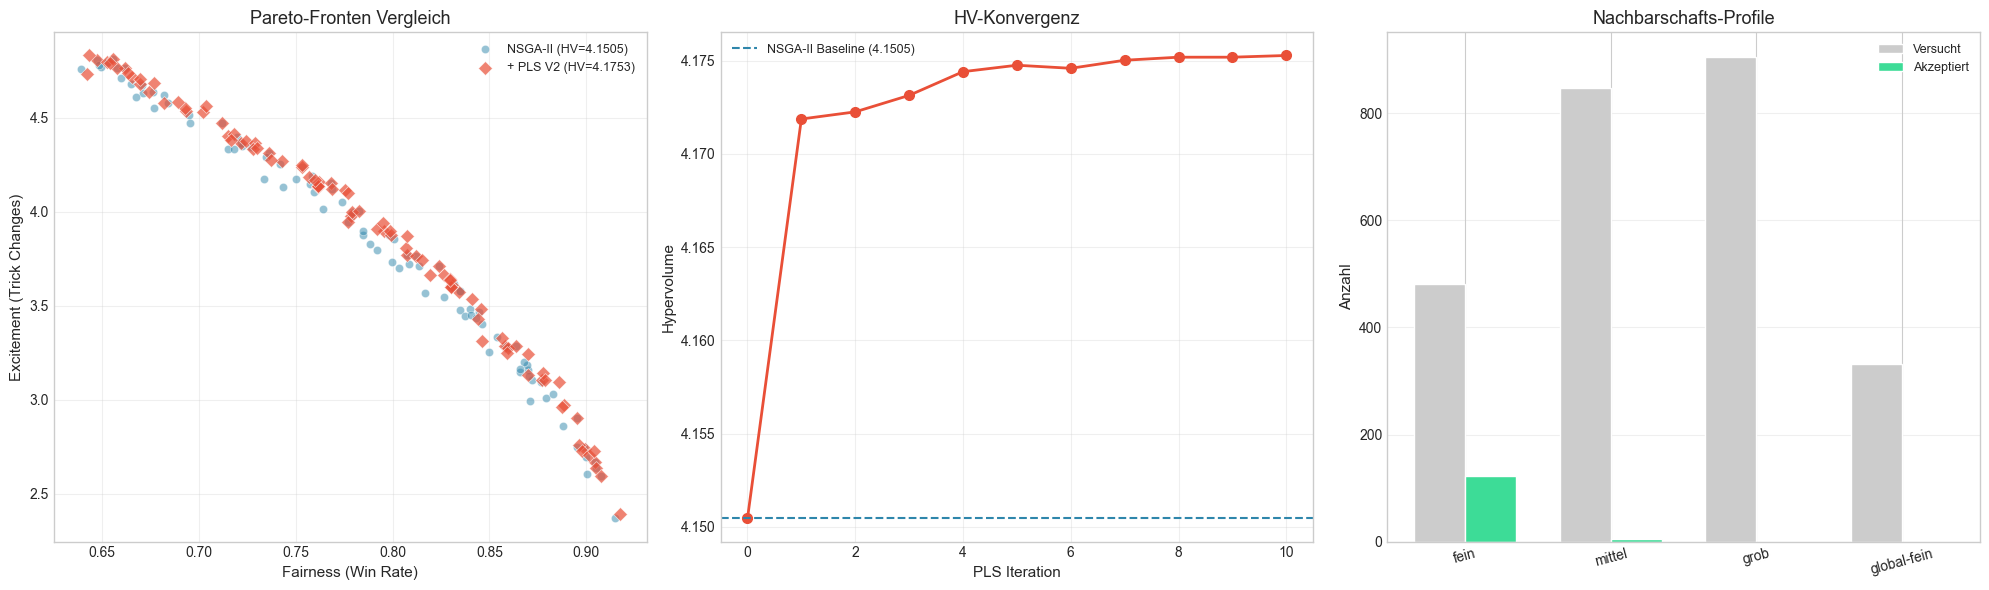

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Pareto-Fronten Vergleich ---
ax = axes[0]
ax.scatter(-reeval_F[:, 0], -reeval_F[:, 1], c='#2E86AB', alpha=0.5, s=35,
           label=f'NSGA-II (HV={reeval_hv:.4f})', zorder=2, edgecolors='white', linewidth=0.5)
ax.scatter(-pls_F[:, 0], -pls_F[:, 1], c='#E94F37', alpha=0.7, s=50, marker='D',
           label=f'+ PLS V2 (HV={pls_hv:.4f})', zorder=3, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Fairness (Win Rate)', fontsize=11)
ax.set_ylabel('Excitement (Trick Changes)', fontsize=11)
ax.set_title('Pareto-Fronten Vergleich', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 2: HV Convergence ---
ax = axes[1]
iterations = [h['iteration'] for h in pls_history]
hvs = [h['hypervolume'] for h in pls_history]
ax.plot(iterations, hvs, 'o-', color='#E94F37', markersize=7, linewidth=2)
ax.axhline(y=reeval_hv, color='#2E86AB', linestyle='--', linewidth=1.5,
           label=f'NSGA-II Baseline ({reeval_hv:.4f})')
ax.set_xlabel('PLS Iteration', fontsize=11)
ax.set_ylabel('Hypervolume', fontsize=11)
ax.set_title('HV-Konvergenz', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: Profil-Erfolgsraten ---
ax = axes[2]
labels = list(pls_profile_stats.keys())
tried = [pls_profile_stats[l]['tried'] for l in labels]
accepted = [pls_profile_stats[l]['accepted'] for l in labels]
x_pos = range(len(labels))
width = 0.35
ax.bar([p - width/2 for p in x_pos], tried, width, label='Versucht', color='#CCCCCC', edgecolor='white')
ax.bar([p + width/2 for p in x_pos], accepted, width, label='Akzeptiert', color='#3DDC97', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Anzahl', fontsize=11)
ax.set_title('Nachbarschafts-Profile', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pls_v2_results.svg', format='svg', bbox_inches='tight')
plt.savefig(PLOTS_DIR / 'pls_v2_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Validierung mit R=10000

In [26]:
R_VALIDATION = 10000

print(f"Validierung der PLS-Front mit R={R_VALIDATION}...")
start_val = time.time()

validated_F = []
for i, x in enumerate(pls_X):
    f_val = evaluate_single(sim, x, R_VALIDATION)
    validated_F.append(f_val)
    if (i + 1) % 25 == 0 or i == 0:
        elapsed = time.time() - start_val
        eta = elapsed / (i+1) * (len(pls_X) - i - 1)
        print(f"  [{i+1:3d}/{len(pls_X)}] {elapsed:.0f}s, ~{eta:.0f}s ETA")

validated_F = np.array(validated_F)

validated_hv = HV(ref_point=REF_POINT)(validated_F)
print(f"\nValidierung in {time.time()-start_val:.0f}s")
print(f"  HV (PLS, R={R_PLS}):       {pls_hv:.6f}")
print(f"  HV (Validated, R={R_VALIDATION}): {validated_hv:.6f}")


Validierung in 23s
  HV (PLS, R=5000):       4.175269
  HV (Validated, R=10000): 4.139481


In [27]:
# Auch initiale Front mit R=10000 validieren für fairen Vergleich
print(f"Validierung der initialen Front mit R={R_VALIDATION}...")
start_val2 = time.time()

initial_validated_F = []
for i, x in enumerate(initial_X):
    f_val = evaluate_single(sim, x, R_VALIDATION)
    initial_validated_F.append(f_val)
    if (i + 1) % 25 == 0 or i == 0:
        elapsed = time.time() - start_val2
        eta = elapsed / (i+1) * (len(initial_X) - i - 1)
        print(f"  [{i+1:3d}/{len(initial_X)}] {elapsed:.0f}s, ~{eta:.0f}s ETA")

initial_validated_F = np.array(initial_validated_F)
initial_validated_hv = HV(ref_point=REF_POINT)(initial_validated_F)

print(f"\nFINALER VERGLEICH (beide mit R={R_VALIDATION}):")
print(f"  NSGA-II:       HV = {initial_validated_hv:.6f}")
print(f"  NSGA-II + PLS: HV = {validated_hv:.6f}")
print(f"  Differenz:     ΔHV = {validated_hv - initial_validated_hv:+.6f} "
      f"({(validated_hv - initial_validated_hv) / initial_validated_hv * 100:+.3f}%)")


FINALER VERGLEICH (beide mit R=10000):
  NSGA-II:       HV = 4.155663
  NSGA-II + PLS: HV = 4.139481
  Differenz:     ΔHV = -0.016182 (-0.389%)


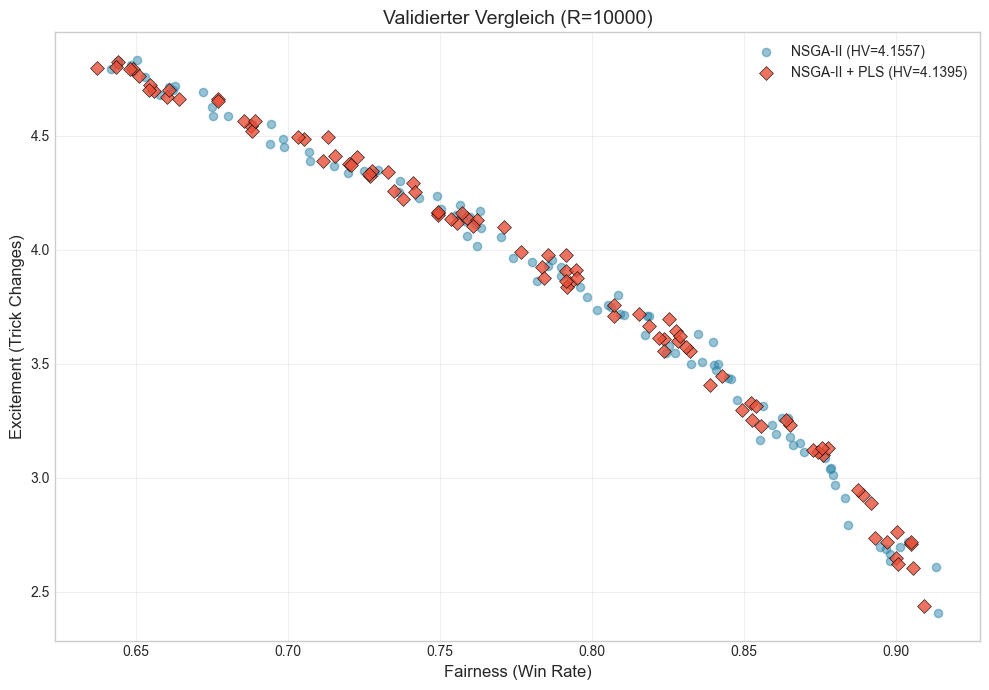

In [28]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(-initial_validated_F[:, 0], -initial_validated_F[:, 1], c='#2E86AB', alpha=0.5, s=35,
           label=f'NSGA-II (HV={initial_validated_hv:.4f})', zorder=1)
ax.scatter(-validated_F[:, 0], -validated_F[:, 1], c='#E94F37', alpha=0.8, s=50, marker='D',
           label=f'NSGA-II + PLS (HV={validated_hv:.4f})', zorder=2,
           edgecolors='black', linewidth=0.5)

ax.set_xlabel('Fairness (Win Rate)', fontsize=12)
ax.set_ylabel('Excitement (Trick Changes)', fontsize=12)
ax.set_title(f'Validierter Vergleich (R={R_VALIDATION})', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pls_v2_validated.svg', format='svg', bbox_inches='tight')
plt.savefig(PLOTS_DIR / 'pls_v2_validated.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Ergebnisse speichern

In [29]:
np.save(RESULTS_DIR / 'pls_v2_pareto_front_X.npy', pls_X)
np.save(RESULTS_DIR / 'pls_v2_pareto_front_F.npy', pls_F)
np.save(RESULTS_DIR / 'pls_v2_validated_F.npy', validated_F)

pls_results = {
    'config': {
        'algorithm': 'Pareto Local Search V2 (CRN + Multi-Scale)',
        'base_algorithm': 'NSGA-II (optimierte Hyperparameter)',
        'K': K, 'L': L,
        'R_pls': R_PLS,
        'R_validation': R_VALIDATION,
        'n_neighbors': N_NEIGHBORS,
        'neighbor_profiles': [{k: v for k, v in p.items()} for p in NEIGHBOR_PROFILES],
        'max_iterations': MAX_ITERATIONS,
        'seed': SEED
    },
    'initial_front': {
        'n_solutions': len(initial_F),
        'hypervolume_R2500': float(initial_hv),
        'hypervolume_R5000': float(reeval_hv),
        'hypervolume_R10000': float(initial_validated_hv)
    },
    'pls_front': {
        'n_solutions': int(len(pls_F)),
        'hypervolume_R5000': float(pls_hv),
        'hypervolume_R10000': float(validated_hv),
        'fairness_range': [float(-pls_F[:,0].max()), float(-pls_F[:,0].min())],
        'excitement_range': [float(-pls_F[:,1].max()), float(-pls_F[:,1].min())]
    },
    'improvement': {
        'hv_R5000_absolute': float(pls_hv - reeval_hv),
        'hv_R5000_relative_pct': float((pls_hv - reeval_hv) / reeval_hv * 100),
        'hv_R10000_absolute': float(validated_hv - initial_validated_hv),
        'hv_R10000_relative_pct': float((validated_hv - initial_validated_hv) / initial_validated_hv * 100),
        'total_evaluations': int(pls_history[-1]['evaluations']),
        'total_time_minutes': float(total_time / 60)
    },
    'profile_stats': {k: v for k, v in pls_profile_stats.items()},
    'history': [{'iteration': h['iteration'], 'archive_size': h['archive_size'],
                 'hypervolume': float(h['hypervolume']), 'evaluations': h['evaluations'],
                 'added': h.get('added', 0), 'removed': h.get('removed', 0)
                } for h in pls_history]
}

with open(RESULTS_DIR / 'pls_v2_results.json', 'w') as f:
    json.dump(pls_results, f, indent=2)

print("Ergebnisse gespeichert:")
for f in ['pls_v2_pareto_front_X.npy', 'pls_v2_pareto_front_F.npy',
          'pls_v2_validated_F.npy', 'pls_v2_results.json']:
    print(f"  {RESULTS_DIR / f}")

Ergebnisse gespeichert:
  ../results/pls_v2_pareto_front_X.npy
  ../results/pls_v2_pareto_front_F.npy
  ../results/pls_v2_validated_F.npy
  ../results/pls_v2_results.json


## 11. Zusammenfassung

In [30]:
print("ZUSAMMENFASSUNG: Pareto Local Search V2")
print("=" * 60)
print(f"\nMethode: NSGA-II → PLS mit CRN + Multi-Scale Nachbarschaft")
print(f"\nAusgangslage (NSGA-II):")
print(f"  Lösungen: {len(initial_F)}")
print(f"  HV (R=5000): {reeval_hv:.6f}")
print(f"  HV (R=10000): {initial_validated_hv:.6f}")
print(f"\nNach PLS V2:")
print(f"  Lösungen: {len(pls_F)}")
print(f"  HV (R=5000): {pls_hv:.6f}")
print(f"  HV (R=10000): {validated_hv:.6f}")
print(f"\nVerbesserung (R=10000, fair):")
print(f"  ΔHV: {validated_hv - initial_validated_hv:+.6f}")
print(f"  Relativ: {(validated_hv - initial_validated_hv) / initial_validated_hv * 100:+.3f}%")
print(f"\nAufwand:")
print(f"  Evaluations: {pls_history[-1]['evaluations']}")
print(f"  Laufzeit: {total_time/60:.1f} Minuten")
print(f"\nBestes Profil:")
best_profile = max(pls_profile_stats.items(),
                   key=lambda x: x[1]['accepted']/max(x[1]['tried'],1))
print(f"  {best_profile[0]}: {best_profile[1]['accepted']}/{best_profile[1]['tried']} akzeptiert")

ZUSAMMENFASSUNG: Pareto Local Search V2

Methode: NSGA-II → PLS mit CRN + Multi-Scale Nachbarschaft

Ausgangslage (NSGA-II):
  Lösungen: 99
  HV (R=5000): 4.150457
  HV (R=10000): 4.155663

Nach PLS V2:
  Lösungen: 94
  HV (R=5000): 4.175269
  HV (R=10000): 4.139481

Verbesserung (R=10000, fair):
  ΔHV: -0.016182
  Relativ: -0.389%

Aufwand:
  Evaluations: 5674
  Laufzeit: 14.4 Minuten

Bestes Profil:
  fein: 123/481 akzeptiert
